In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from scipy.signal import correlate
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

In diesem Notebook soll als ergänzung versucht werden die Regendaten sauber modellieren zu können. Dazu sollen die Daten alle auf monatliche Mittel aggregiert werden. Im Anschluss ist dann das Ziel ein Seasonal Decompose Model zu erstellen, welches die Saisonalität und den Trend der Daten abbildet. Falls dies sauberer funktionieren sollte, als mit den tagesdaten, können wir noch versuchen auch monatliche Wasserstände mit mehr Variablen vorherzusagen.

In [2]:
# ursprüngliches df der betrachteten Koeffizienten
df_important_coef = pd.read_csv('../data/prediction/df_important_coef.csv')

df_orig_level = df_important_coef['waterlevel(m)']
df_orig_level.index = pd.to_datetime(df_important_coef['date'])
df_orig_temp = df_important_coef['temperature_mean(degC)']
df_orig_temp.index = pd.to_datetime(df_important_coef['date'])
df_orig_vol = df_important_coef['discharge_vol(m3/s)']
df_orig_vol.index = pd.to_datetime(df_important_coef['date'])
df_orig_rain = df_important_coef['precipitation(mm/d)']
df_orig_rain.index = pd.to_datetime(df_important_coef['date'])

In [3]:
# Monatliche Daten zu allen Zeitreihen erstellen
df_level_monthly = df_orig_level.resample('ME').mean()
df_temp_monthly = df_orig_temp.resample('ME').mean()
df_vol_monthly = df_orig_vol.resample('ME').mean()
df_rain_monthly = df_orig_rain.resample('ME').mean()

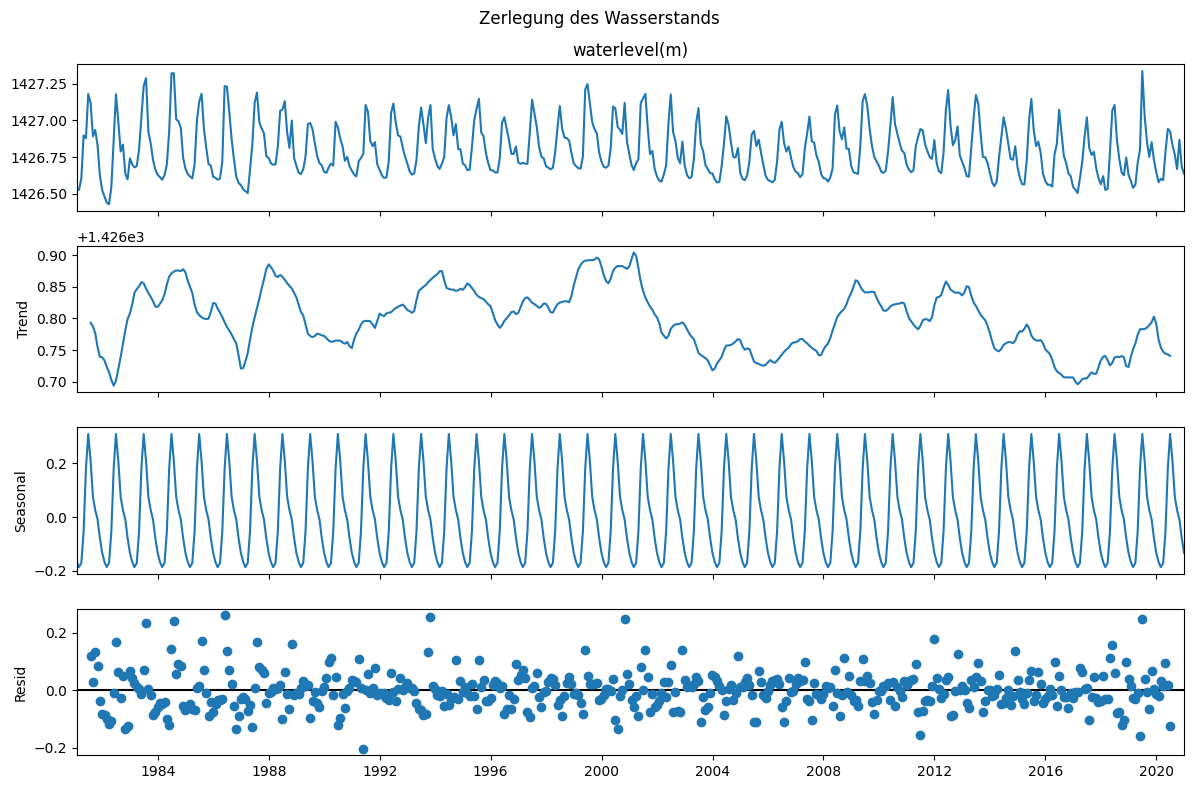

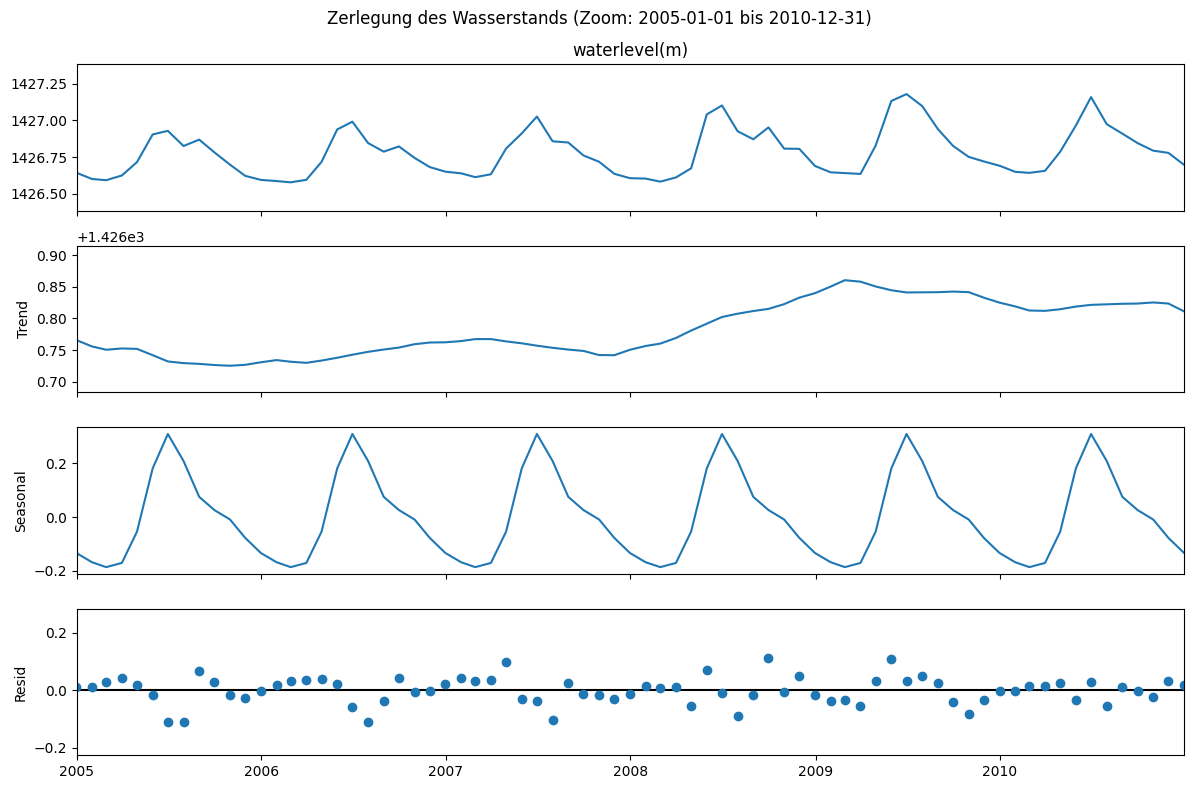

ADF p-Wert der Residuen für 'Zerlegung des Wasserstands': 0.000000
✓ Residuen sind stationaer


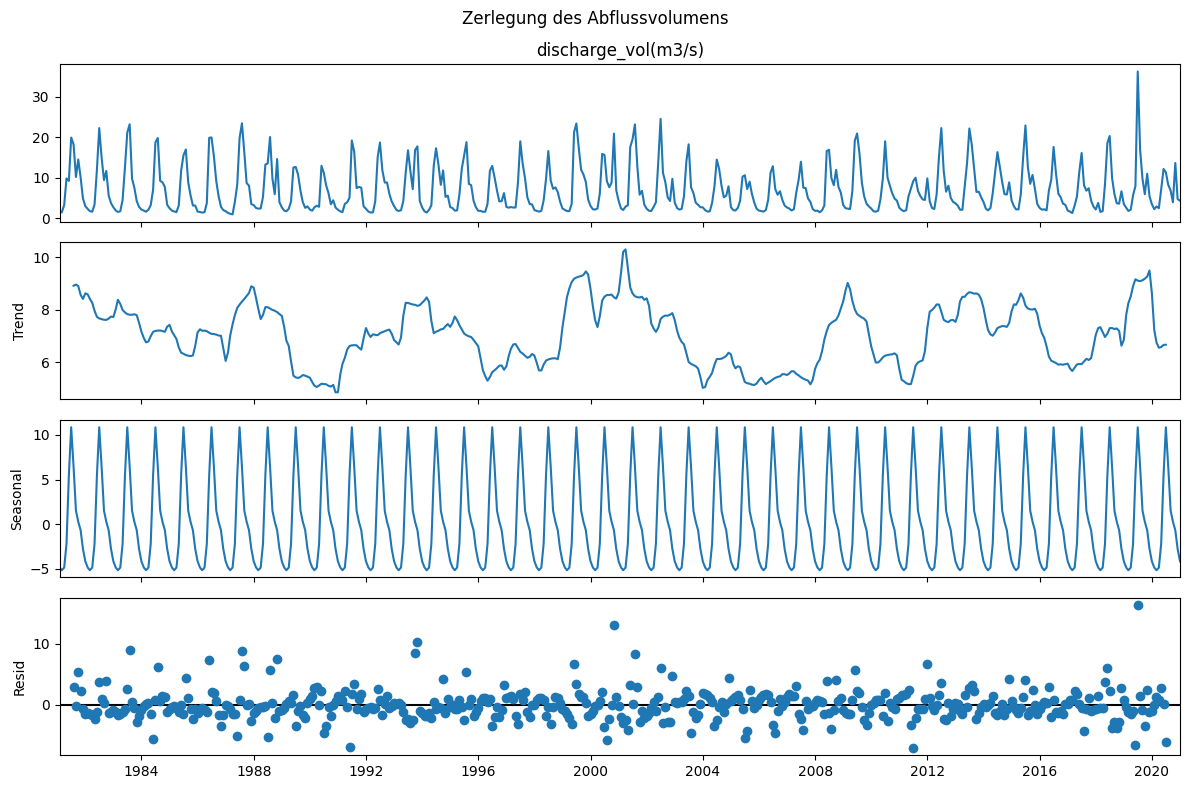

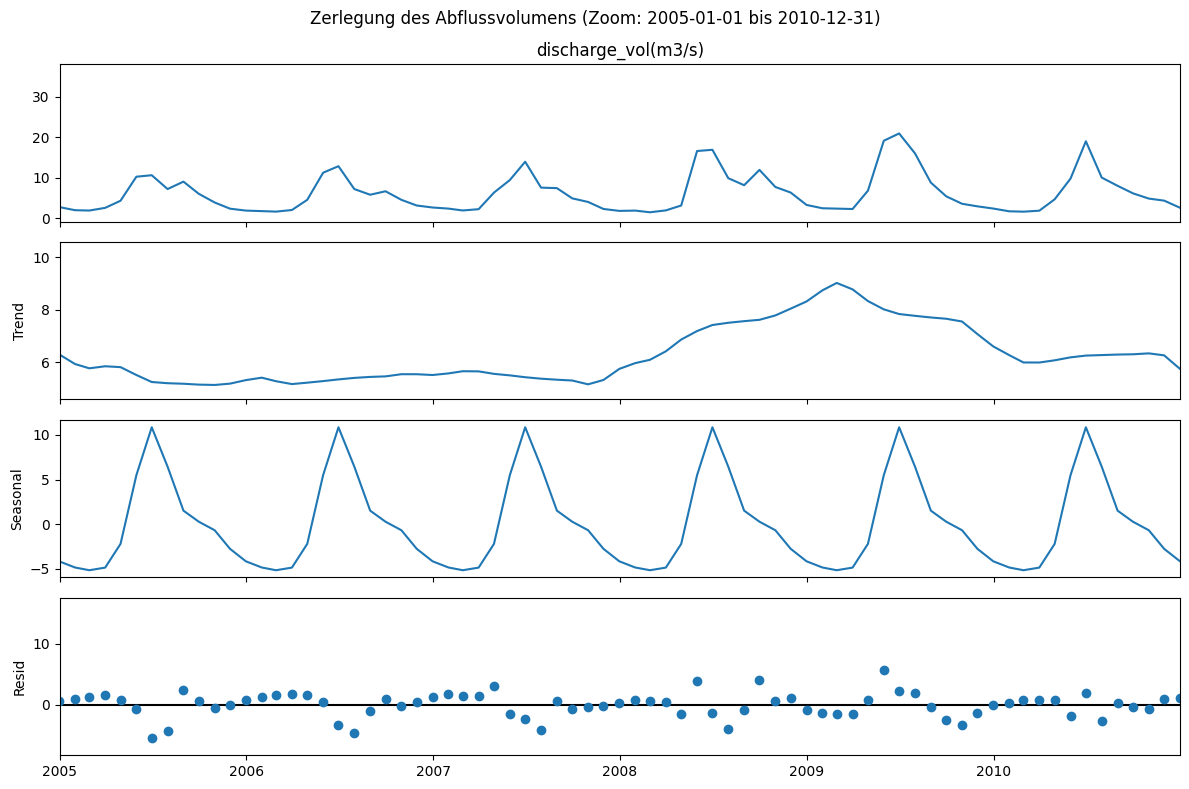

ADF p-Wert der Residuen für 'Zerlegung des Abflussvolumens': 0.000000
✓ Residuen sind stationaer


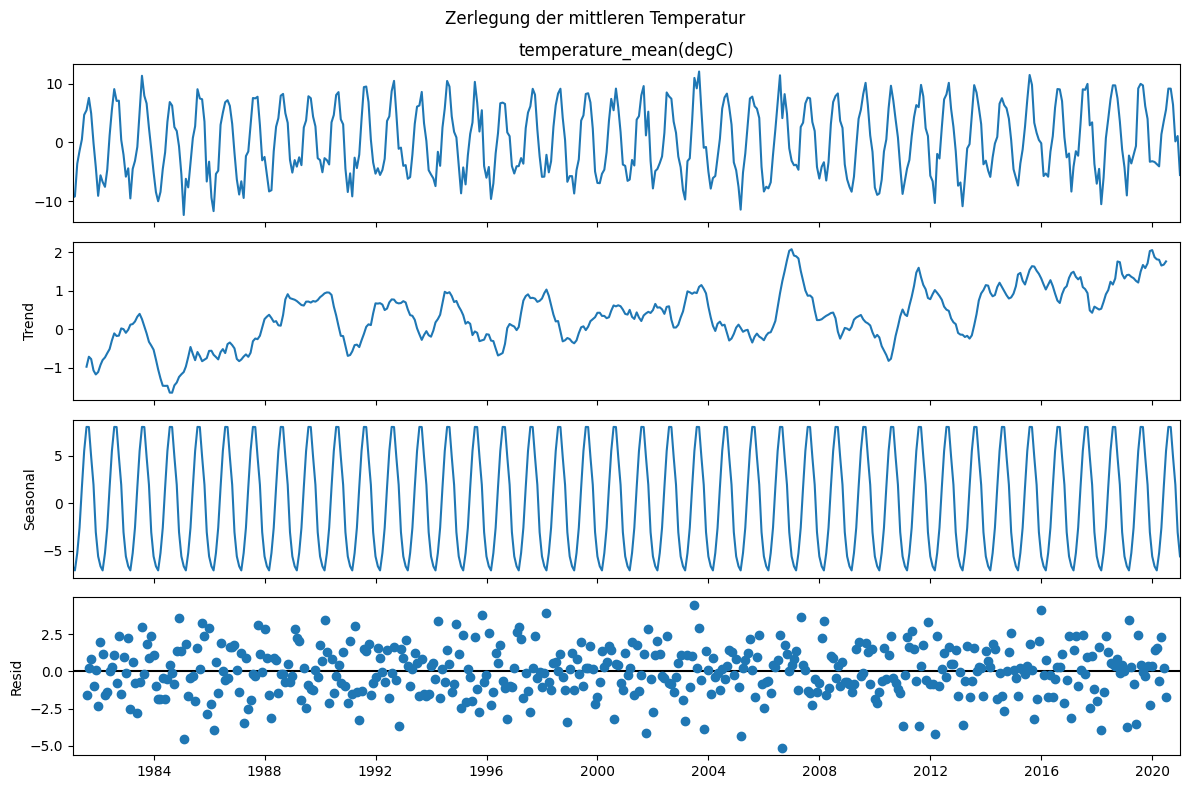

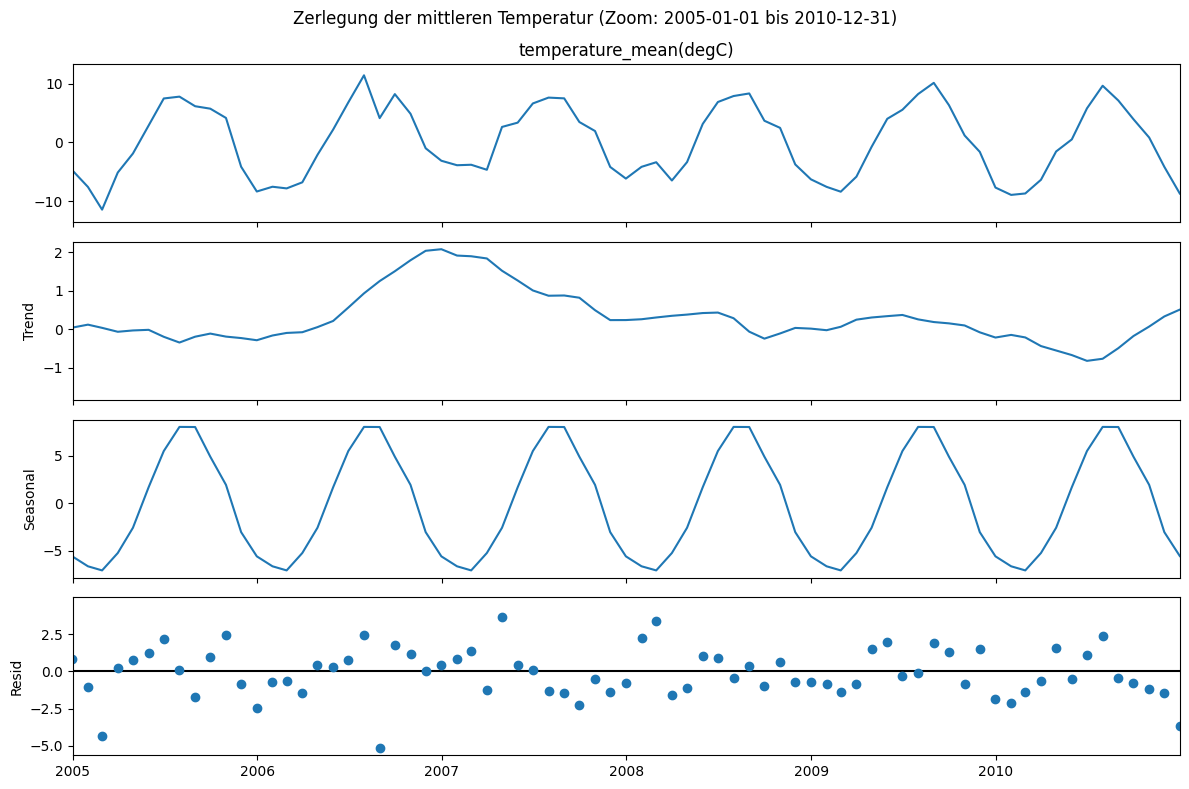

ADF p-Wert der Residuen für 'Zerlegung der mittleren Temperatur': 0.000000
✓ Residuen sind stationaer


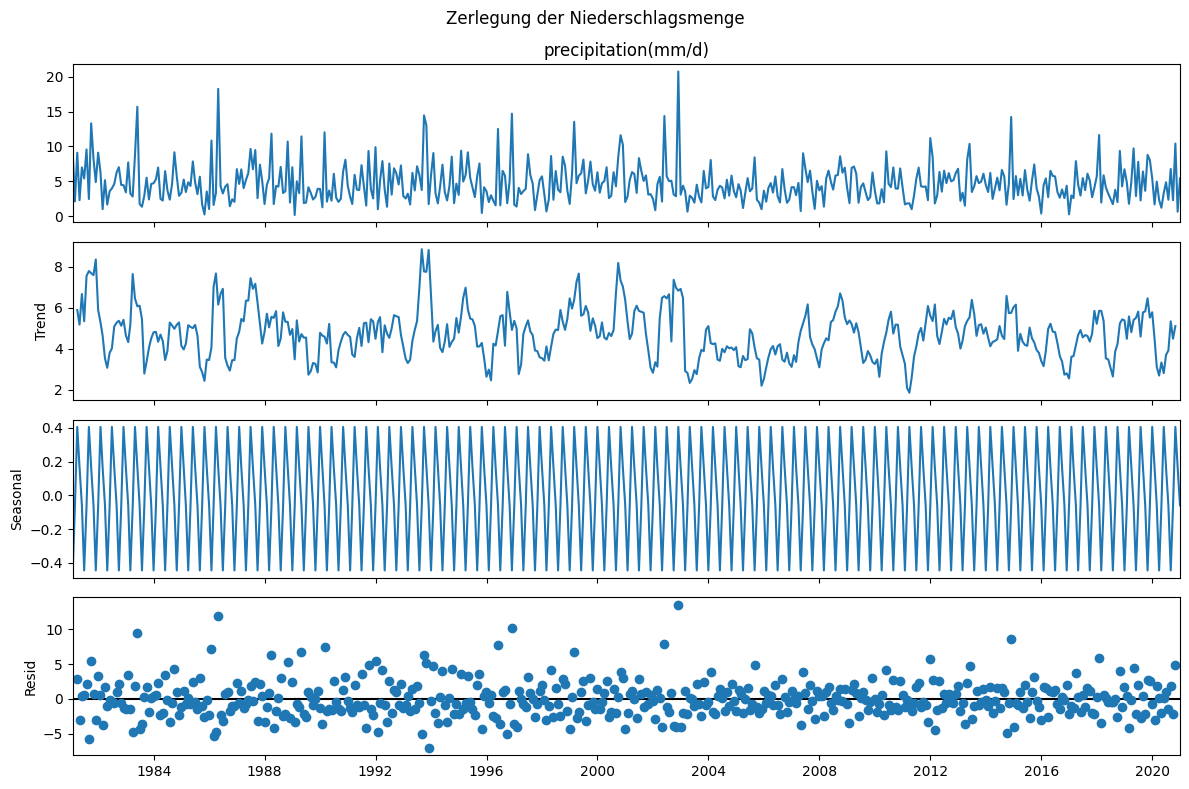

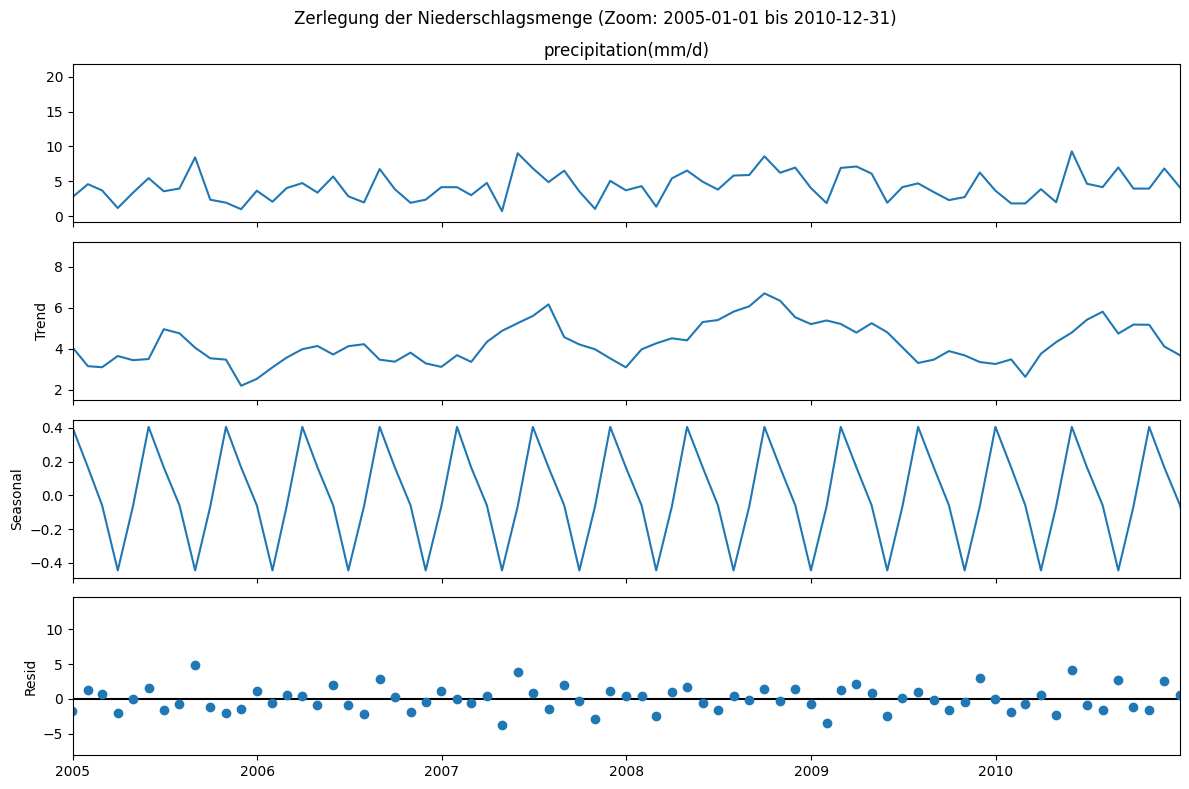

ADF p-Wert der Residuen für 'Zerlegung der Niederschlagsmenge': 0.000000
✓ Residuen sind stationaer


In [4]:
# Seasonale Zerlegung durchführen
df_level_comp_month = seasonal_decompose(df_level_monthly, model='additive', period=12)
df_temp_comp_month = seasonal_decompose(df_temp_monthly, model='additive', period=12)
df_vol_comp_month = seasonal_decompose(df_vol_monthly, model='additive', period=12)
df_percip_comp_month = seasonal_decompose(df_rain_monthly, model='additive', period=5)

# Visualisieren der Zerlegung
def plot_decomposition_zoom(decomp_result, title, start_date='2005-01-01', end_date='2010-12-31'):
    fig = decomp_result.plot()
    fig.suptitle(title)
    fig.set_size_inches(12,8)
    plt.tight_layout()
    plt.show()

    fig = decomp_result.plot()
    fig.suptitle(f"{title} (Zoom: {start_date} bis {end_date})")
    fig.set_size_inches(12,8)
    plt.xlim(pd.to_datetime(start_date), pd.to_datetime(end_date))
    plt.tight_layout()
    plt.show()

    # Berechnen und ausgeben des ADF-Tests der Residuen
    resid = decomp_result.resid.dropna()
    adf_result = adfuller(resid)
    print(f"ADF p-Wert der Residuen für '{title}': {adf_result[1]:.6f}")
    if adf_result[1] < 0.05:
        print("✓ Residuen sind stationaer")
    else:
        print("✗ Residuen nicht stationaer")


dfs_decomposed = (df_level_comp_month, df_vol_comp_month, df_temp_comp_month, df_percip_comp_month)

titles = [
    'Zerlegung des Wasserstands',
    'Zerlegung des Abflussvolumens',
    'Zerlegung der mittleren Temperatur',
    'Zerlegung der Niederschlagsmenge'
]

for decomp, title in zip(dfs_decomposed, titles):
    plot_decomposition_zoom(decomp, title, start_date='2005-01-01', end_date='2010-12-31')

Durch die Aggregation auf Monatsdaten gehen uns natürlich viele Datenpunkte verloren, dadurch wird die Datenbasis kleine und wir können weniger genauere Modelle erstellen. Jedoch ist es so möglich die Regendaten besser zu modellieren. Zu unserem Erstaunen ist es aber so, dass die Regendaten nicht jährlich saisonal sind, sondern eher alle 5 Monate. Die Daten sind laut ADF Test stationär, auch bei betrachtung der Plots über alle Jahre, sehen die Daten gut aus. Bei den gezoomten Plots sieht man aber leichte Systematiken in den Residuen, welche mit den Saisonalitäten zusammenhängen könnten.

Ziel ist es jetzt auch hier zu schauen, wie die ACF und PACF Plots auf den Residuen aussehen und ob wir hier vielleicht auch ARIMA Modelle erstellen können.

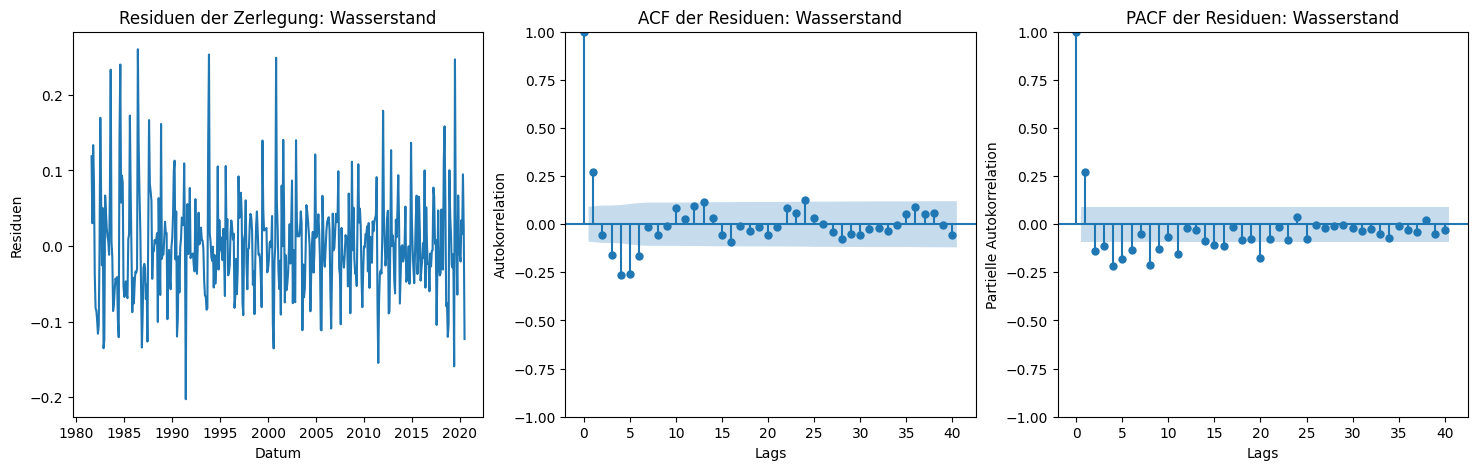

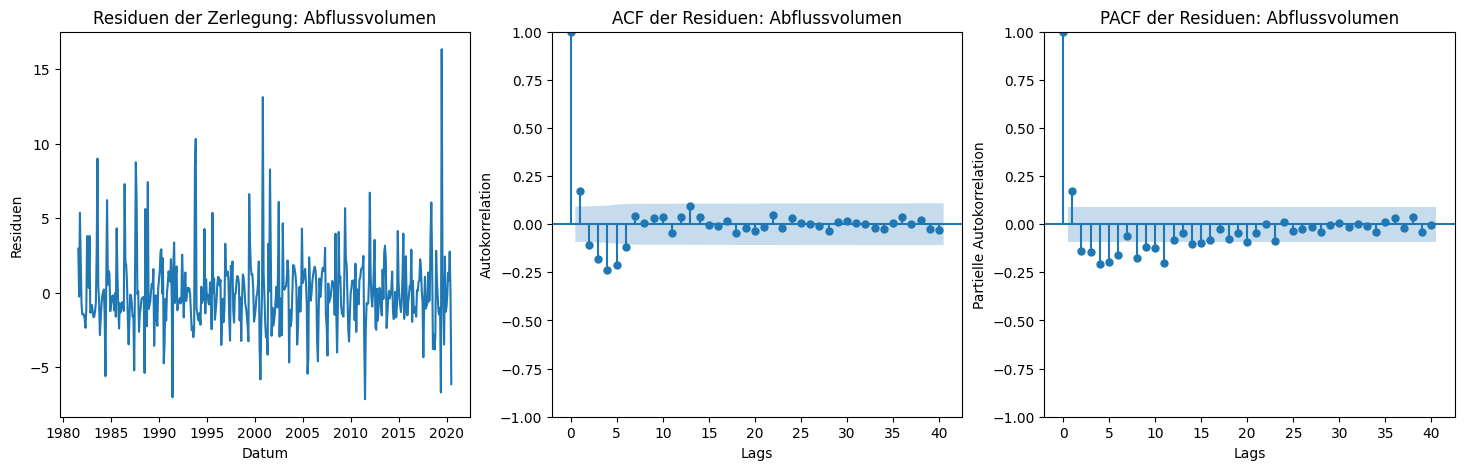

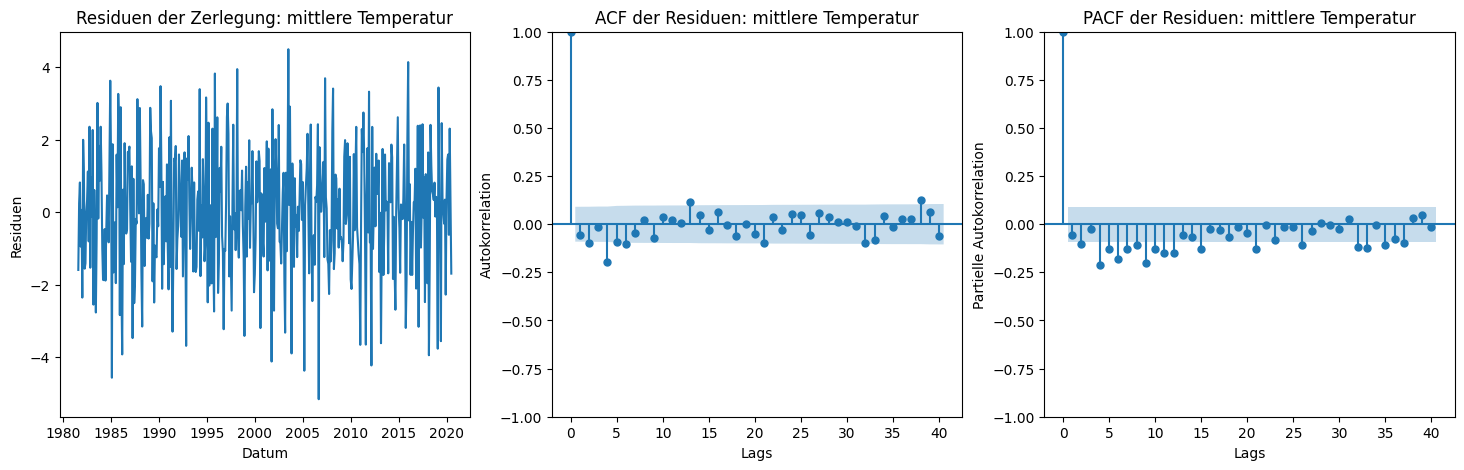

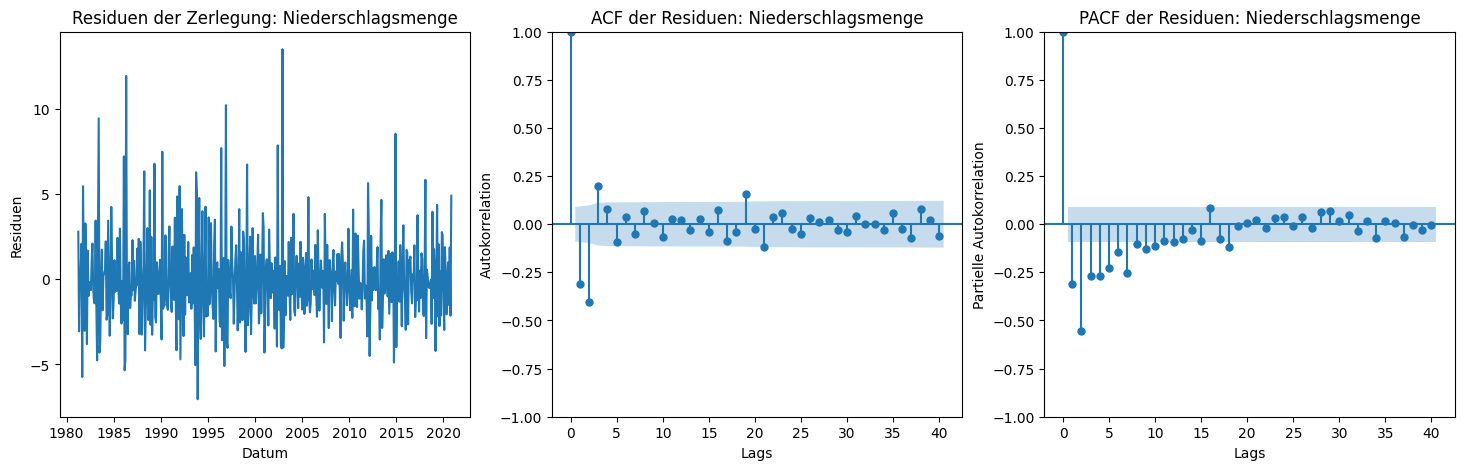

In [15]:
def acf_pacf_plots_decomposed(resid, title):
    # Plot Residuen
    plt.figure(figsize=(18,5))
    plt.subplot(1,3,1)
    plt.plot(resid)
    plt.title(f'Residuen der Zerlegung: {title}')
    plt.xlabel('Datum')
    plt.ylabel('Residuen')

    # ACF Plot
    plt.subplot(1,3,2)
    plot_acf(resid, ax=plt.gca(), lags=40)
    plt.title(f'ACF der Residuen: {title}')
    plt.xlabel('Lags')
    plt.ylabel('Autokorrelation')

    # PACF Plot
    plt.subplot(1,3,3)
    plot_pacf(resid, ax=plt.gca(), lags=40)
    plt.title(f'PACF der Residuen: {title}')
    plt.xlabel('Lags')
    plt.ylabel('Partielle Autokorrelation')
    plt.show()

dfs_decomposed = (df_level_comp_month, df_vol_comp_month, df_temp_comp_month, df_percip_comp_month)

titles = [
    'Wasserstand',
    'Abflussvolumen',
    'mittlere Temperatur',
    'Niederschlagsmenge'
]

for decomp, title in zip(dfs_decomposed, titles):
    resid = decomp.resid.dropna()
    acf_pacf_plots_decomposed(resid, title)